# Plot Robustness Results

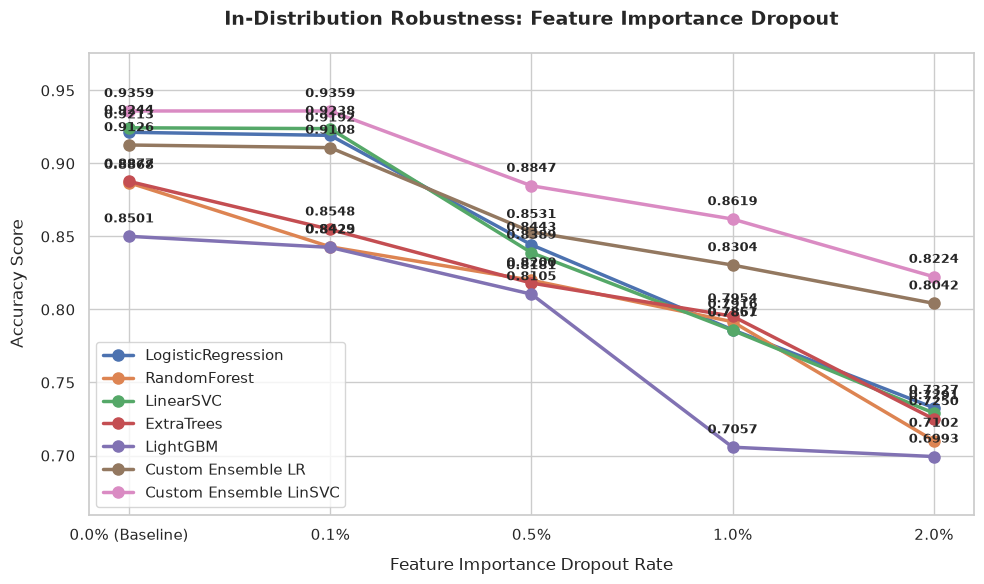

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

dropout_rates = ['0.0% (Baseline)', '0.1%', '0.5%', '1.0%', '2.0%']

data = {
    'LogisticRegression': [0.9213, 0.9192, 0.8443, 0.7861, 0.7327],
    'RandomForest': [0.8868, 0.8429, 0.8200, 0.7916, 0.7102], 
    'LinearSVC': [0.9244, 0.9238, 0.8389, 0.7857, 0.7291],
    'ExtraTrees': [0.8877, 0.8548, 0.8181, 0.7954, 0.7250],
    'LightGBM': [0.8501, 0.8425, 0.8105, 0.7057, 0.6993],
    'Custom Ensemble LR': [0.9126, 0.9108, 0.8531, 0.8304, 0.8042],
    'Custom Ensemble LinSVC': [0.9359, 0.9359, 0.8847, 0.8619, 0.8224],
}

plt.figure(figsize=(10, 6), dpi=100)

for model_name, accuracies in data.items():
    line = plt.plot(dropout_rates, accuracies, marker='o', linewidth=2.5, markersize=8, label=model_name)
    
    for i, acc in enumerate(accuracies):
        plt.annotate(
            f"{acc:.4f}", 
            (dropout_rates[i], acc), 
            textcoords="offset points", 
            xytext=(0, 10), 
            ha='center', 
            fontsize=9,
            fontweight='semibold'
        )

plt.xlabel('Feature Importance Dropout Rate', fontsize=12, labelpad=10)
plt.ylabel('Accuracy Score', fontsize=12, labelpad=10)
plt.title('In-Distribution Robustness: Feature Importance Dropout', fontsize=14, fontweight='bold', pad=20)

all_values = [val for accs in data.values() for val in accs]
plt.ylim(min(all_values) - 0.04, max(all_values) + 0.04)

plt.legend(loc='lower left', fontsize=11, frameon=True)

plt.tight_layout()

plt.show()